## 0. Importing PyTorch and setting up device-agnostic code

In [ ]:
import torch
from torch import nn

torch.__version__

'2.11.0+cu128'

In [ ]:
# Setup device-agnostic code
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
    )

## 1. Get data

Our dataset is a subset of the Food101 dataset.

In [ ]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path('data')
image_path = data_path / 'pizza_steak_sushi'

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f'{image_path} directory exists.')
else:
    print(f'Did not find {image_path} directory, creating one...')
    image_path.mkdir(parents=True, exist_ok=True)


# Download
with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print('Download complete.')
    f.write(request.content)


# Unzip
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print('Unzipping data...')
    zip_ref.extractall(image_path)


data/pizza_steak_sushi directory exists.
Download complete.
Unzipping data...


In [ ]:
# İncelemek istediğiniz büyük dosya (örneğin indirdiğiniz zip veya ağırlık dosyası)
dosya = Path("data/pizza_steak_sushi.zip")

boyut_byte = dosya.stat().st_size

# MB ve GB dönüşümleri
boyut_mb = boyut_byte / (1024 ** 2)
boyut_gb = boyut_byte / (1024 ** 3)

print(f"{boyut_mb:.2f} MB")
print(f"{boyut_gb:.2f} GB")

15.01 MB
0.01 GB


## 2. Becoming one with the data

In [ ]:
image_path

PosixPath('data/pizza_steak_sushi')

In [ ]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [ ]:
# Setup train and testing paths
train_dir = image_path / 'train'
test_dir = image_path / 'test'

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing and image

In [ ]:
import random
from PIL import Image

# Set seed
random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

image_path_list

[PosixPath('data/pizza_steak_sushi/train/sushi/1214108.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/307738.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2021381.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3426958.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/93139.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/377047.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2720223.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1232045.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2674024.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2871052.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/121940.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1552504.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1575445.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3360207.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1957449.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2641778.jpg'),
 PosixPath('d

In [ ]:
# Farklı uzantıya sahip resim dosyaları için kullanılabilecek yol
from pathlib import Path

# Desteklemek istediğiniz tüm uzantılar (küçük harf olarak)
valid_extensions = {".jpg", ".jpeg", ".png", ".webp"}

# Tek geçişte filtreleme
image_path_list_2 = [
    p for p in image_path.glob("*/*/*")
    if p.suffix.lower() in valid_extensions
]

image_path_list_2

[PosixPath('data/pizza_steak_sushi/train/sushi/1214108.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/307738.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2021381.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3426958.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/93139.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/377047.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2720223.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1232045.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2674024.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2871052.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/121940.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1552504.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1575445.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/3360207.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/1957449.jpg'),
 PosixPath('data/pizza_steak_sushi/train/sushi/2641778.jpg'),
 PosixPath('d

In [ ]:
'''
Bu yapı sayesinde klasör ağacı kaç katman derinleşirse derinleşsin ara klasörler otomatik elenir,
büyük/küçük harf farkları normalize edilir ve sadece tanımladığınız uzantılara sahip dosyaların
Path nesneleri listeye aktarılır.'''

from pathlib import Path

# Ana veri dizini
image_path = Path("data")  # Projenizdeki kök veri klasörünün yolu

# Kabul edilen resim uzantıları
valid_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# Derinlikten bağımsız tüm alt klasörleri tarayıp geçerli dosyaları listeleme
image_path_list_3 = [
    p for p in image_path.rglob("*")
    if p.is_file() and p.suffix.lower() in valid_extensions
]

# Kontrol için toplam görsel sayısı ve ilk 3 örnek
print(f"Toplam bulunan görsel sayısı: {len(image_path_list_3)}")
print(image_path_list_3[:10])


Toplam bulunan görsel sayısı: 301
[PosixPath('data/04-pizza-dad.jpeg'), PosixPath('data/pizza_steak_sushi/test/sushi/2385731.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/858157.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/1245193.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/175783.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/3177743.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/3196729.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/1172255.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/1600999.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/3837522.jpg')]


In [ ]:
len(image_path_list), len(image_path_list_2), len(image_path_list_3)

(300, 300, 301)

data/pizza_steak_sushi/train/sushi/3353428.jpg
sushi
sushi
Image size: (512, 512)
Image mode: RGB
Image format: JPEG
Image height: 512
Image width: 512
Image class: sushi


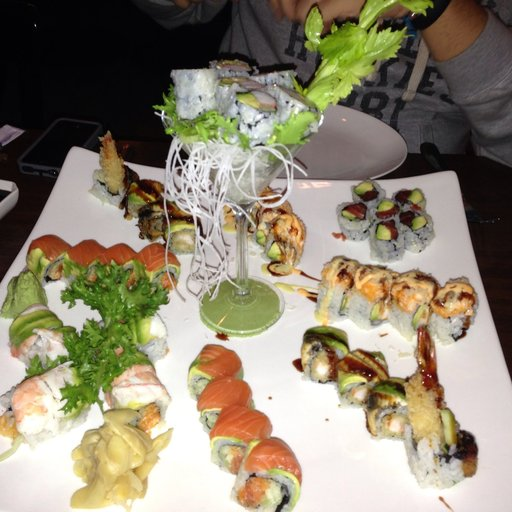

In [ ]:
# 2. Pick a random image path
# Set seed
random.seed(42)
random_image_path = random.choice(image_path_list)

print(random_image_path)

# 3. Get image class from path name
image_class = random_image_path.parent.stem
image_class_2 = random_image_path.parent.name

print(image_class)
print(image_class_2)

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f'Image size: {img.size}')
print(f'Image mode: {img.mode}')
print(f'Image format: {img.format}')
print(f'Image height: {img.height}')
print(f'Image width: {img.width}')
print(f'Image class: {image_class}')
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

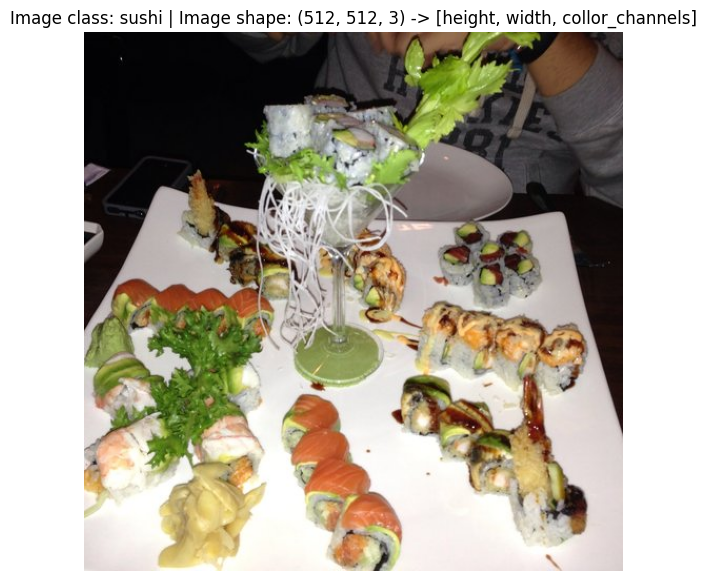

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f'Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, collor_channels]')
plt.axis(False)

## 3. Transforming data

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 3.1 Transforming data with `torchvision.transform`

In [ ]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize((64, 64)),
    # Flip the images randomly
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [ ]:
data_transform(img).shape, np.asarray(img).shape

(torch.Size([3, 64, 64]), (512, 512, 3))

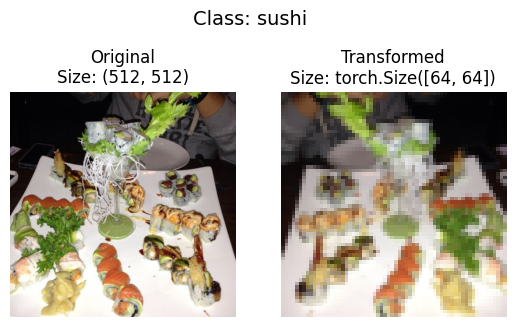

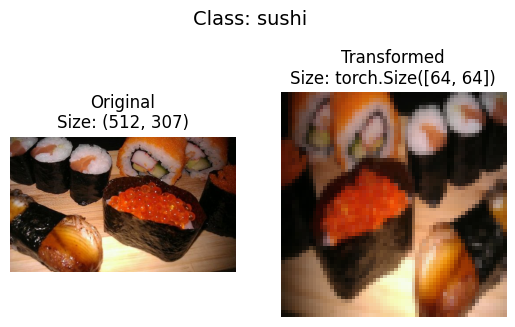

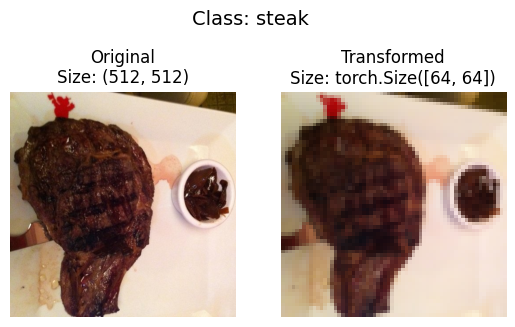

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
  '''
  Plots n transformed images per image path
  '''
  if seed:
    random.seed(42)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f'Original\nSize: {f.size}')
      ax[0].axis('off')

      # Transform and plot target image
      transformed_image = transform(f)
      ax[1].imshow(transformed_image.permute(1, 2, 0))
      ax[1].set_title(f'Transformed\nSize: {transformed_image.shape[-2:]}')
      ax[1].axis('off')

      fig.suptitle(f'Class: {image_path.parent.name}', fontsize=14, y=0.9)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)



## 4.1 Option 1: Loading image data using `ImagaFolder`


In [ ]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None)

print(f'Train data:\n{train_data}\nTest data:\n{test_data}')

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [ ]:
# Get class name as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
# Check the lengths of our dataset
len(train_data), len(test_data)

(225, 75)

In [ ]:
# Index on the train?data Dataset to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f'Image tensor:\n{img}')
print(f'Image shape: {img.shape}')
print(f'Image label: {label} ({class_names[label]})')

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

Image shape: torch.Size([64, 64, 3])


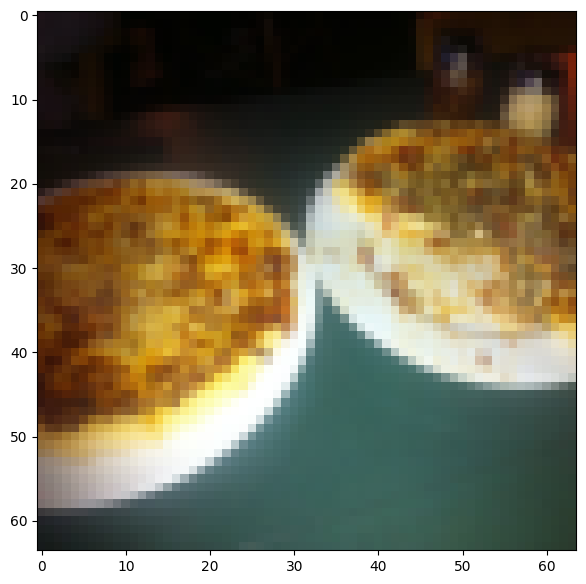

In [ ]:
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)
print(f'Image shape: {img_permute.shape}')

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)

In [ ]:
img, label = test_data[0][0], test_data[0][1]
print(f'Image tensor:\n{img}')
print(f'Image shape: {img.shape}')
print(f'Image label: {label} ({class_names[label]})')

Image tensor:
tensor([[[0.0471, 0.2039, 0.3725,  ..., 0.0824, 0.1333, 0.1020],
         [0.2000, 0.1961, 0.2667,  ..., 0.0784, 0.1255, 0.1137],
         [0.0980, 0.1176, 0.1333,  ..., 0.1059, 0.1255, 0.1255],
         ...,
         [0.0196, 0.0196, 0.0235,  ..., 0.0863, 0.1059, 0.0980],
         [0.0196, 0.0235, 0.0235,  ..., 0.0863, 0.1020, 0.0941],
         [0.0196, 0.0196, 0.0235,  ..., 0.0980, 0.0980, 0.0863]],

        [[0.0196, 0.1255, 0.2471,  ..., 0.0235, 0.0353, 0.0235],
         [0.1333, 0.1216, 0.1608,  ..., 0.0157, 0.0275, 0.0235],
         [0.0588, 0.0667, 0.0784,  ..., 0.0314, 0.0196, 0.0235],
         ...,
         [0.0039, 0.0039, 0.0078,  ..., 0.0196, 0.0235, 0.0196],
         [0.0039, 0.0078, 0.0078,  ..., 0.0196, 0.0235, 0.0196],
         [0.0039, 0.0039, 0.0078,  ..., 0.0314, 0.0235, 0.0196]],

        [[0.0118, 0.0392, 0.0588,  ..., 0.0039, 0.0078, 0.0039],
         [0.0510, 0.0314, 0.0431,  ..., 0.0039, 0.0078, 0.0039],
         [0.0275, 0.0353, 0.0353,  ..., 0.01

Image shape: torch.Size([64, 64, 3])


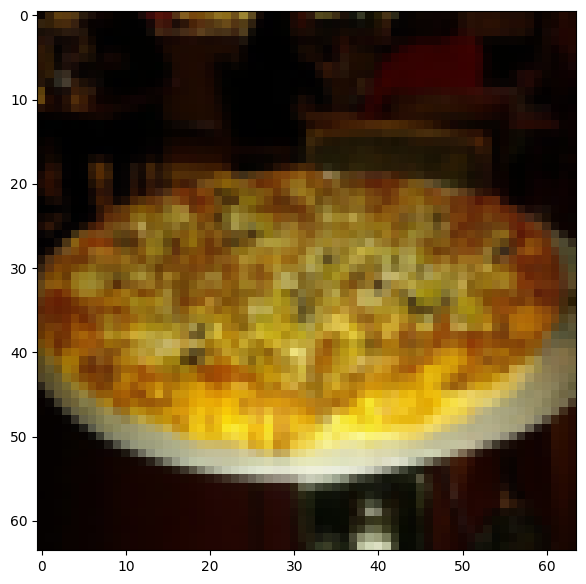

In [ ]:
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)
print(f'Image shape: {img_permute.shape}')

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)

### 4.1 Turn loaded images into `DataLoader`

In [ ]:
import os
os.cpu_count()

2

In [ ]:
# Turn train and test datasets into DataLoader's
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7d2fd81f5fd0>,
 <torch.utils.data.dataloader.DataLoader at 0x7d2fd7fddf90>)

In [ ]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [ ]:
img, label = next(iter(train_dataloader)) # Batch'ler içerisinden ilk batch'i alır ve getirir.
print(f'Image shape: {img.shape}')
print(f'Label shape: {label.shape}')

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


## 5. Option 2: Loading Image Data with a Custom `Dataset`

In [ ]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [ ]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class names using `os.scandir()` to traverse a target directory.
2. Raise an error if the class names aren't found.
3. Trun the class names into a dict and a list and return them.

In [ ]:
# Setup path for target directory
target_directory = train_dir
print(f'Target directory: {target_directory}')

# Get class names as a list
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found


Target directory: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [ ]:
list(os.scandir(target_directory))

[<DirEntry 'sushi'>, <DirEntry 'steak'>, <DirEntry 'pizza'>]

In [ ]:
def find_classes(dir: str) -> Tuple[List[str], Dict[str, int]]:
  '''
  Searches target directory for images and returns class
  names and a dictionary of class names and indices.
  '''
  # 1. Get the class names by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(dir) if entry.is_dir())

  # 2. Raise an error if class names not be found
  if not classes:
    raise FileNotFoundError(f'No class folder found in {dir}.')

  # 3. Create a dictionary of index labels
  class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
  return classes, class_to_idx

In [ ]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
target_directory

PosixPath('data/pizza_steak_sushi/train')

## 5.2 Create a custom `Dataset` to replicate `ImageFolder`

1. Subclass `torch.utils.data.Dataset`.
2. Init our subclass with a target direcitory.
3. Create several attributes:
  * path - paths of our images
  * transform - the transform we'd like to use
  * classes - a list of the target classes
  * class_to_idx - a dict of the target classses mapped to integer labels
4. Create a function to `load_images()`, this function will open an image.
5. Overwrite the `__len()__` method to return the length of our dataset
6. Overwrite the `__get()__` method to return a given sample when passed an index

In [ ]:
# Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass toch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2. Initialize our custom dataset
  def __init__(self, targ_dir: str, transforms=None):

    # 3. Create class attributes
    # Get all of the image paths
    self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))
    # Setup transforms
    self.transforms = transforms
    # Create classes and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Create a function to load images
  def load_image(self, index: int) -> Image.Image:
    'Opens an image via a path and returns it.'
    return Image.open(self.paths[index])  # <-- image_path yerine self.paths[index] olmalı

  # 5. Overwrite __len__()
  def __len__(self) -> int:
    'Returns the total number of samples.'
    return len(self.paths)

  # 6. Overwrite __getitem__() method to return a particular sample
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    'Returns one sample of data, data and label (X, y).'
    img = self.load_image(index)
    class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
    class_idx = self.class_to_idx[class_name]

    # Transform if necessary
    if self.transforms:
      return self.transforms(img), class_idx
    else:
      return img, class_idx


In [ ]:
# Create a transform
from torchvision import transforms

# Create a transform
train_transforms = transforms.Compose([
                                        transforms.Resize((64, 64)),
                                        transforms.RandomHorizontalFlip(p=0.5),
                                        transforms.ToTensor()
])

test_transforms = transforms.Compose([
                                        transforms.Resize((64, 64)),
                                        transforms.ToTensor()
])

In [ ]:
# Test out ImageFlterCustom
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transforms=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transforms=test_transforms)

In [ ]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7d2fd81f6510>,
 <__main__.ImageFolderCustom at 0x7d2fd80c0190>)

In [ ]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [ ]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [ ]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

### 5.3 Create a function to display random images

In [ ]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    # 1. n sınırını kontrol etme
    if n > 10:
        n = 10
        display_shape = False
        print("For display purposes, n should be less than or equal to 10.")

    # 2. Seed ayarı (hem torch hem random için)
    if seed:
        random.seed(seed)
        torch.manual_seed(seed)

    # 3. Rastgele indeksleri seçme
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 4. Çizim alanını hazırlama
    plt.figure(figsize=(16, 8))

    # 5. Görselleri döngüyle çizdirme
    for i, targ_sample in enumerate(random_samples_idx):
        # Tek seferde veriyi çekme
        targ_image, targ_label = dataset[targ_sample]

        # PyTorch (C, H, W) -> Matplotlib (H, W, C) dönüşümü
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Çizim adımı
        plt.subplot(1, n, i + 1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")

        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nShape: {targ_image_adjust.shape}"
            plt.title(title)

    plt.show()

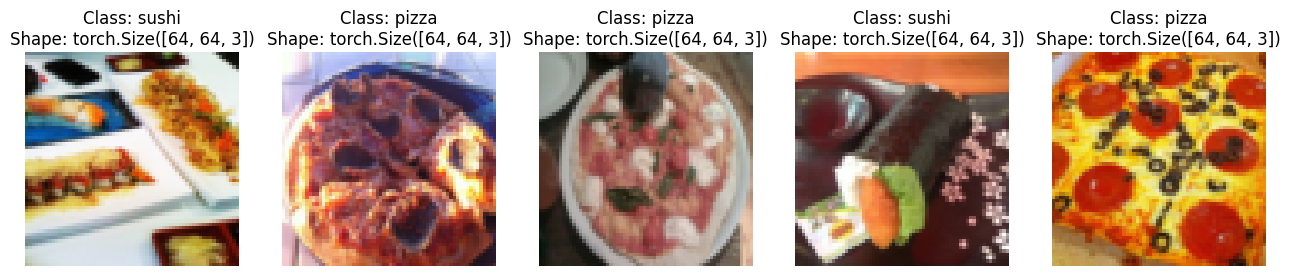

In [ ]:
# Display random images from the ImageFolder created Dataset
display_random_images(dataset=train_data,
                      classes=train_data.classes,
                      n=5,
                      seed=42)

### 5.4 Turn custom loaded images into DataLoader


In [ ]:
from torch.utils.data import DataLoader

# Create DataLoader's
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=1,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=1,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7d2fd7e32710>,
 <torch.utils.data.dataloader.DataLoader at 0x7d2fd822e8b0>)

In [ ]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))
print(f'Image shape: {img_custom.shape}')
print(f'Label shape: {label_custom.shape}')

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


## 6. Other forms of transforms (data augmentation)

In [ ]:
from numpy.matrixlib import test
# Let's look at trivalilaugment
from torchvision import transforms
from PIL import Image

train_transforms = transforms.Compose([
                                        transforms.Resize((224, 224)),
                                        transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                        transforms.ToTensor()
])

test_transforms = transforms.Compose([
                                        transforms.Resize((224, 224)),
                                        transforms.ToTensor()
])

In [ ]:
# Get all image paths
import random
from PIL import Image

# Set seed
random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.rglob("*.jpg"))

image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/sushi/2385731.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/858157.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1245193.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/175783.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3177743.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3196729.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1172255.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1600999.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3837522.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2521706.jpg')]

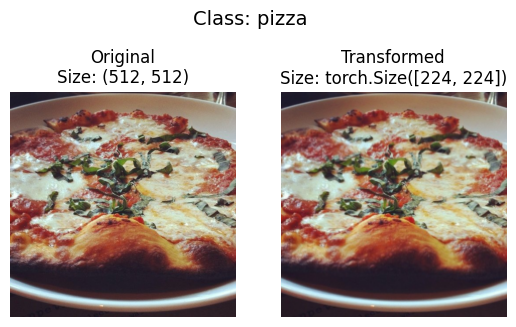

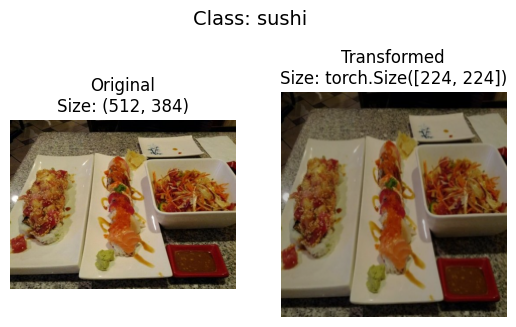

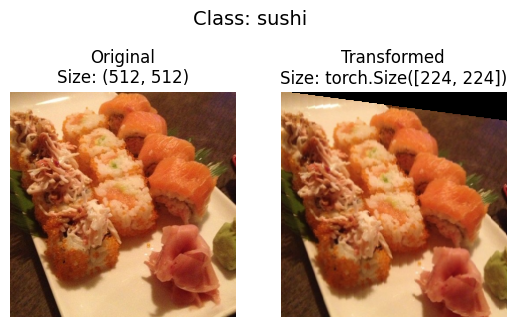

In [ ]:
plot_transformed_images(image_paths=image_path_list,
                        transform=train_transforms,
                        n=3,
                        seed=None)

## 7. Model 0: TinyVGG without data augmentation

### 7.1 Creating transforms and loading data for Model0

In [ ]:
# Create simple transforms
from torchvision import transforms

simple_transform = transforms.Compose([
                                       transforms.Resize((64, 64)),
                                       transforms.ToTensor()
])

In [ ]:
# 1. Load and transform data
from torchvision import datasets

train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform,
                                         target_transform=None)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform,
                                        target_transform=None)

# 2. Turn the datasets into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of works
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

# Create DataLoader's
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

### 7.2 Create TinyVGG model class

In [ ]:
class TinyVGG(nn.Module):
  '''
  Model architecture copying TinyVGG from CNN Explainer
  '''
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*16*16,
                  out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    print(x.shape)
    x = self.conv_block_2(x)
    print(x.shape)
    x = self.classifier(x)
    print(x.shape)
    return x

In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_simple.classes)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

### 7.3 Try a forward pass on a single image

In [ ]:
# Get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
# Try a forward pass
model_0(image_batch.to(device))

torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])


tensor([[0.0578, 0.0634, 0.0351],
        [0.0657, 0.0650, 0.0398],
        [0.0702, 0.0678, 0.0412],
        [0.0687, 0.0646, 0.0417],
        [0.0625, 0.0613, 0.0355],
        [0.0587, 0.0595, 0.0358],
        [0.0634, 0.0637, 0.0376],
        [0.0653, 0.0615, 0.0376],
        [0.0678, 0.0621, 0.0349],
        [0.0620, 0.0599, 0.0371],
        [0.0607, 0.0628, 0.0387],
        [0.0638, 0.0589, 0.0352],
        [0.0658, 0.0611, 0.0369],
        [0.0703, 0.0689, 0.0330],
        [0.0557, 0.0571, 0.0356],
        [0.0632, 0.0642, 0.0388],
        [0.0639, 0.0616, 0.0375],
        [0.0605, 0.0600, 0.0374],
        [0.0623, 0.0627, 0.0368],
        [0.0740, 0.0676, 0.0400],
        [0.0621, 0.0613, 0.0361],
        [0.0632, 0.0599, 0.0366],
        [0.0662, 0.0627, 0.0334],
        [0.0637, 0.0622, 0.0394],
        [0.0670, 0.0666, 0.0363],
        [0.0650, 0.0601, 0.0405],
        [0.0639, 0.0597, 0.0395],
        [0.0733, 0.0687, 0.0412],
        [0.0697, 0.0631, 0.0402],
        [0.062

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model

In [ ]:
# Install torchinfo, import if it's available
try:
  from torchinfo import summary
except:
  print("[INFO] Couldn't find torchinfo... installing it.")
  !pip install -q torchinfo
  from torchinfo import summary


from torchinfo import summary

summary(model=model_0,
        input_size=(1, 3, 64, 64))

torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([1, 3])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [ ]:
summary(
    model=model_0,
    input_size=(32, 3, 64, 64),
    col_names=["input_size", "output_size", "num_params", "trainable", "mult_adds"],
    col_width=20,
    row_settings=["var_names"],
    depth=3,
    device=device
)

torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable            Mult-Adds
TinyVGG (TinyVGG)                        [32, 3, 64, 64]      [32, 3]              --                   True                 --
├─Sequential (conv_block_1)              [32, 3, 64, 64]      [32, 10, 32, 32]     --                   True                 --
│    └─Conv2d (0)                        [32, 3, 64, 64]      [32, 10, 64, 64]     280                  True                 36,700,160
│    └─ReLU (1)                          [32, 10, 64, 64]     [32, 10, 64, 64]     --                   --                   --
│    └─Conv2d (2)                        [32, 10, 64, 64]     [32, 10, 64, 64]     910                  True                 119,275,520
│    └─ReLU (3)                          [32, 10, 64, 64]     [32, 10, 64, 64]     --                   --                   --
│    └─MaxPool2d (4)                     [32, 10, 64, 64]     [32, 10, 32, 32]  

### 7.5 Create train and test loop functions

In [ ]:
# Create train_step()

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device=device):
  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  for batch, (X, y) in enumerate(dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate accuracy matric
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [ ]:
# Create a test step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device=device):
  # Put the model in eval mode
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. Calculate the loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate the accuracy
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()

In [ ]:
from tqdm.auto import tqdm

# Create a train function that takes in various
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device=device):

  # Create empty results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": [],}

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    # Print out what's happening
    print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
    )

    # Update results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # 6. Return the filled results at the end of the epochs
  return results

### 7.7 Train and evaulate model 0

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_simple.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                         train_dataloader=train_dataloader_simple,
                         test_dataloader=test_dataloader_simple,
                         optimizer=optimizer,
                         loss_fn=loss_fn,
                         epochs=NUM_EPOCHS,
                         device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([1, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([11, 10, 32, 32])
torch.Size([11, 10, 16, 16])
torch.Size([11, 3])
Epoch: 1 | train_loss: 1.1078 | train_acc: 0.2578 | test_loss: 1.1362 | test_acc: 0.2604
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16]

In [ ]:
model_0_results

{'train_loss': [1.107835665345192,
  1.084644891321659,
  1.1152610778808594,
  1.0990343689918518,
  1.0989169925451279],
 'train_acc': [0.2578125, 0.42578125, 0.29296875, 0.2890625, 0.29296875],
 'test_loss': [1.1362075408299763,
  1.1621679464975994,
  1.169467528661092,
  1.134170413017273,
  1.143341064453125],
 'test_acc': [0.2604166666666667,
  0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666]}

### 7.8 Plot the loss curves of Model0




In [ ]:
# Get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):
  """
  Plots training curves of a results dictionary
  """
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))
  plt.figure(figsize=(15, 7))

  # Plot loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  # Plot accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel
  plt.legend()

  plt.show()

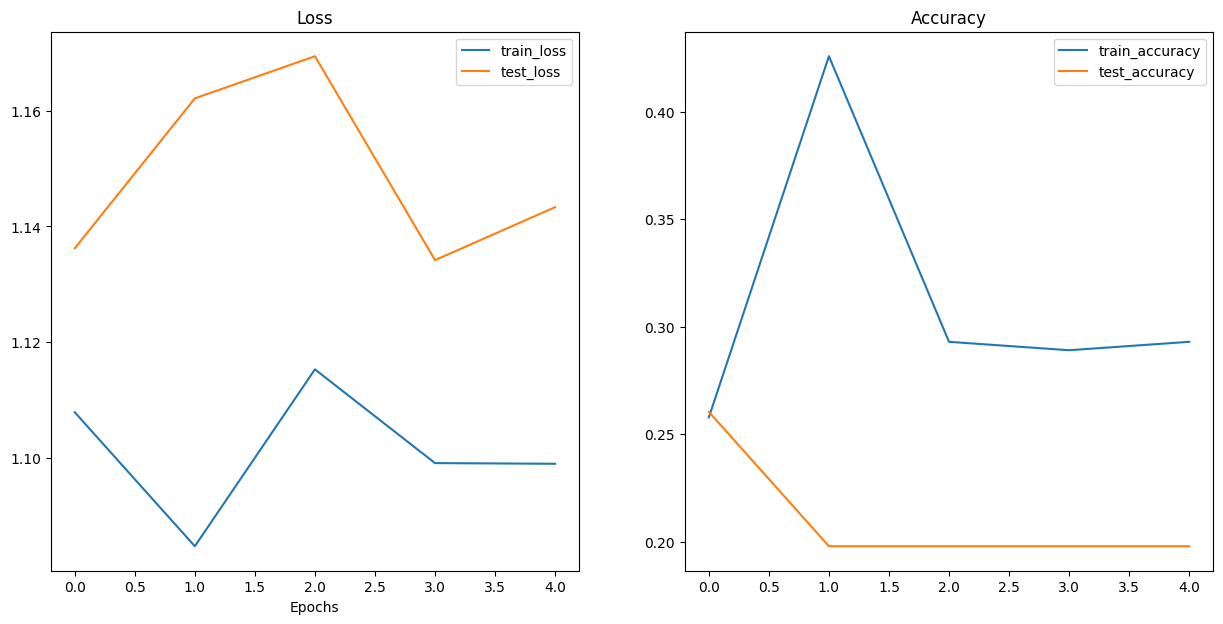

In [ ]:
plot_loss_curves(model_0_results)

## 8. What should an ideal loss curve look like?

A loss curve is one of the most helpful ways to troubleshoot a model

## 9. Model 1: TinyVGG with Data Augmentation

Now let's try another modelling experiment this time using the same model as before with some data augmentation.


### 9.1 Create transform with data augmentation

In [ ]:
# Create training transform with TriviailAugment
from torchvision import transforms
train_transform_trivial = transforms.Compose([
                                              transforms.Resize((64, 64)),
                                              transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                              transforms.ToTensor()
])

# Create test transform
test_transform_simple = transforms.Compose([
                                            transforms.Resize((64, 64)),
                                            transforms.ToTensor()
])


## 9.2 Create training and test `Dataset` 's and `DataLoader` 's with adata augmentation

In [ ]:
# Trun image folders into Datasets
from torchvision import datasets

train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_transform_trivial,
                                            target_transform=None)

test_data_augmented = datasets.ImageFolder(root=test_dir,
                                           transform=test_transform_simple,
                                           target_transform=None)

In [ ]:
# Turn our Dataserts into DataLoaders
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                         batch_size=BATCH_SIZE,
                                         num_workers=NUM_WORKERS,
                                         shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_augmented,
                                       batch_size=BATCH_SIZE,
                                       num_workers=NUM_WORKERS,
                                       shuffle=False)

### 9.3 Construct and train model 1

In [ ]:
# Create model_1 and send it to the target device
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_augmented.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 100

# Setup loss function
loss_fn = nn.CrossEntropyLoss()

# Setup optimizer
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train(model=model_1,
                         train_dataloader=train_dataloader_augmented,
                         test_dataloader=test_dataloader_simple,
                         optimizer=optimizer,
                         loss_fn=loss_fn,
                         epochs=NUM_EPOCHS,
                         device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/100 [00:00<?, ?it/s]

torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([1, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16])
torch.Size([32, 3])
torch.Size([11, 10, 32, 32])
torch.Size([11, 10, 16, 16])
torch.Size([11, 3])
Epoch: 1 | train_loss: 1.1076 | train_acc: 0.2500 | test_loss: 1.1062 | test_acc: 0.2604
torch.Size([32, 10, 32, 32])
torch.Size([32, 10, 16, 16]

In [ ]:
model_1_results

{'train_loss': [1.1075638383626938,
  1.0791212618350983,
  1.081126794219017,
  1.129147857427597,
  1.090067632496357,
  1.0953855365514755,
  1.0877515226602554,
  1.1059608459472656,
  1.1210448443889618,
  1.0756820142269135,
  1.0584399700164795,
  1.0054457262158394,
  1.015893615782261,
  1.018642172217369,
  1.0043934658169746,
  0.9879989922046661,
  1.0697545036673546,
  0.9335344508290291,
  0.9070370271801949,
  0.9589563831686974,
  0.9427155554294586,
  1.0405910685658455,
  0.9997469708323479,
  0.8914053067564964,
  0.9662501215934753,
  1.058612696826458,
  0.9772952497005463,
  0.9791958332061768,
  0.9242141246795654,
  0.9421478658914566,
  0.8071498423814774,
  0.9711783826351166,
  0.8529839664697647,
  0.8488653004169464,
  0.9819086641073227,
  0.9563001841306686,
  0.9074125587940216,
  0.8953559473156929,
  0.8356510326266289,
  1.0034330561757088,
  0.9240532889962196,
  0.8971936777234077,
  0.9718775302171707,
  0.8660243675112724,
  1.123316429555416,
  0

### 9.4 Plot the loss curves of model 1

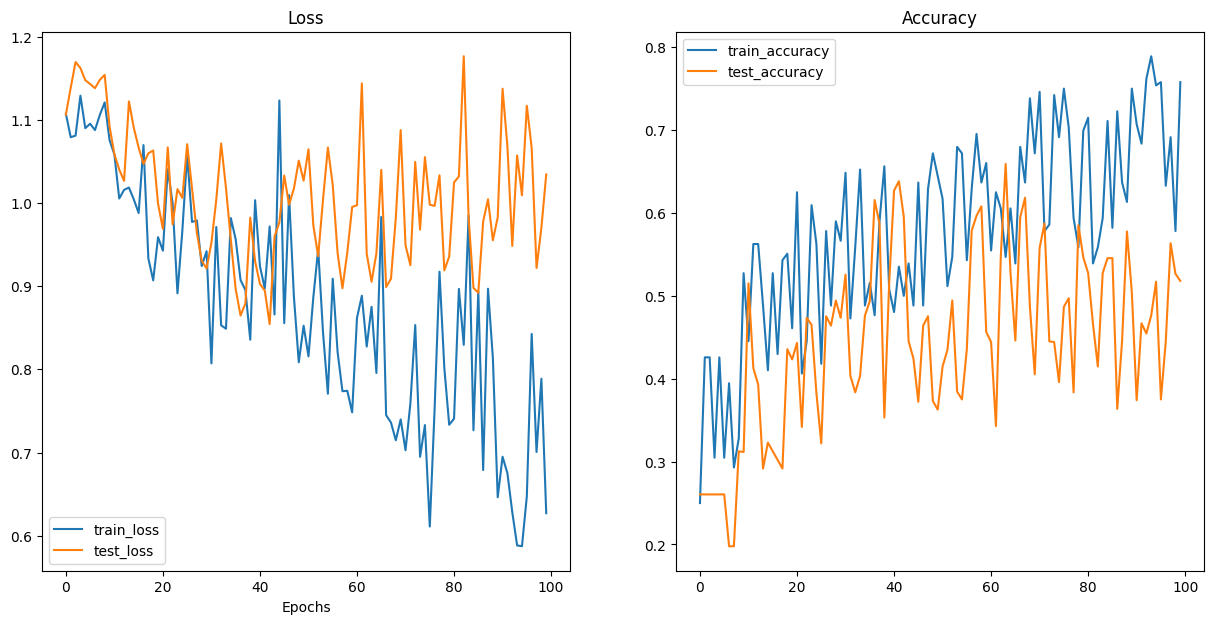

In [ ]:
plot_loss_curves(model_1_results)

## 10. Compare model results

1. Hard coding
2. PyTorch + Tensorboard
3. Weight & Biases
4. MLFlow

In [ ]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)

In [ ]:
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.107836,0.257812,1.136208,0.260417
1,1.084645,0.425781,1.162168,0.197917
2,1.115261,0.292969,1.169468,0.197917
3,1.099034,0.289062,1.134170,0.197917
4,1.098917,0.292969,1.143341,0.197917


ValueError: x and y must have same first dimension, but have shapes (5,) and (100,)

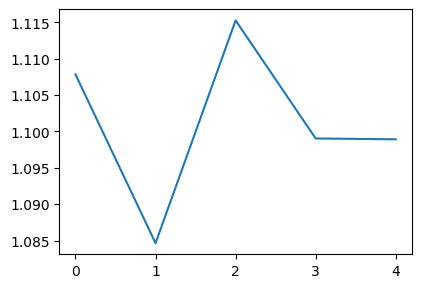

In [ ]:
# Setup a plot
plt.figure(figsize=(10, 7))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0 train loss")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1 train loss")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0 test loss")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1 test loss")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train acc
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0 train acc")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1 train acc")
plt.title("Train acc")
plt.xlabel("Epochs")
plt.legend()

# Plot test acc
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0 test acc")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1 test acc")
plt.title("Test acc")
plt.xlabel("Epochs")
plt.legend()

## 11. Making a prediction on a custom image

In [ ]:
# Download custom image
from pathlib import Path
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Kaydedilecek yol ve dosya adı
custom_image_path = Path("data/04-pizza-dad.jpeg")

# Varsa bozuk (404 içeren) eski dosyayı temizle
if custom_image_path.is_file():
    custom_image_path.unlink()

# Doğru 'raw' görsel linki
image_url = "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg"

# Klasör yoksa oluştur
custom_image_path.parent.mkdir(parents=True, exist_ok=True)

# Görseli indir
request = requests.get(image_url)
with open(custom_image_path, "wb") as f:
    f.write(request.content)

print(f"Görsel başarıyla indirildi: {custom_image_path}")

Görsel başarıyla indirildi: data/04-pizza-dad.jpeg


### 11.1 Loading in a custom image with PyTorch

In [ ]:
import torchvision

# Read in custom image
custom_image_unit8 = torchvision.io.read_image(str(custom_image_path))
custom_image_unit8

tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

In [ ]:
custom_image_unit8.shape, custom_image_unit8.ndim, custom_image_unit8.dtype

(torch.Size([3, 4032, 3024]), 3, torch.uint8)

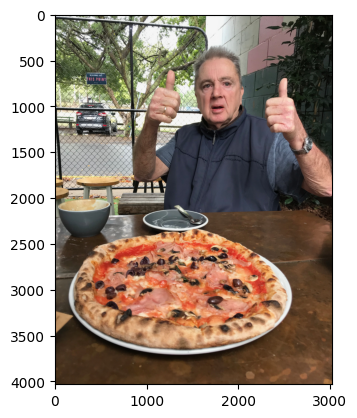

In [ ]:
plt.imshow(custom_image_unit8.permute(1, 2, 0))

### 11.2 Making a prediction on a custom image with a trained PyTorch model

In [ ]:
custom_image_unit8.unsqueeze(dim=0).shape

torch.Size([1, 3, 4032, 3024])

In [ ]:
# Load in the custom image and convert to torch.float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.0
custom_image

tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..., 0.0549, 0.0510, 0.

In [ ]:
# Create transform pipeline to resize image
from torchvision import transforms
custom_image_transform = transforms.Compose([
                                              transforms.Resize((64, 64))
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)
custom_image_transformed.shape, custom_image_transformed.ndim, custom_image_transformed.dtype

(torch.Size([3, 64, 64]), 3, torch.float32)

In [ ]:
custom_image_transformed.shape

torch.Size([3, 64, 64])

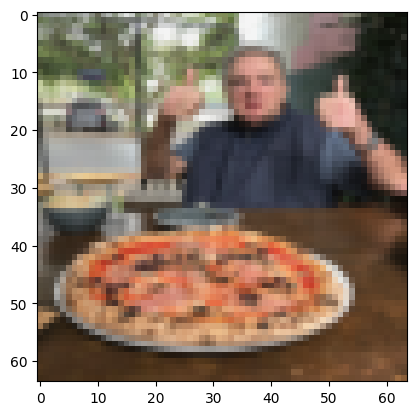

In [ ]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [ ]:
# Trt to make a prediction on an image
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([1, 3])


In [ ]:
custom_image_pred

tensor([[ 0.8512, -1.5009, -1.0897]], device='cuda:0')

In [ ]:
# Convert logits -> prediction probabilities
cuustom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
cuustom_image_pred_probs

tensor([[0.8073, 0.0768, 0.1159]], device='cuda:0')

In [ ]:
# Convert prediction probabilities -> prediction labels
custom_image_pred_labels = torch.argmax(cuustom_image_pred_probs, dim=1).cpu()
custom_image_pred_labels

tensor([0])

In [ ]:
class_names[custom_image_pred_labels]

### 11.3 Putting custom image prediction together: building a function

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device=device):
  """Makes a prediction on a target image with a trained model and plots the image with the prediction"""
  # 1. Load in image
  image = torchvision.io.read_image(str(image_path)).type(torch.float32)
  image = image / 255.0

  # 2. Transform the image
  if transforms is not None:
    image = transform(image)

  # 3. Transform if necessary
  if transform:
    image = transform(image)

  # 4. Make a prediction on image
  model.to(device)
  model.eval()
  with torch.inference_mode():
    image = image.unsqueeze(dim=0)

    image_pred = model(image.to(device))

  # 5. Convert logits -> prediction probabilities
  image_pred_probs = torch.softmax(image_pred, dim=1)

  # 6. Convert prediction probabilities -> prediction labels
  image_pred_labels = torch.argmax(image_pred_probs, dim=1).cpu()
  image_pred_labels_class = class_names[image_pred_labels]

  # 7. Plot the image
  plt.imshow(image.squeeze().permute(1, 2, 0))
  if class_names:
    plt.title(f"Pred: {image_pred_labels_class}, Prob: {image_pred_probs.max():.3f}")
    plt.axis(False)
  else:
    plt.title(f"Pred: {image_pred_labels}, Prob: {image_pred_probs.max():.3f}")
    plt.axis(False)

torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])
torch.Size([1, 3])


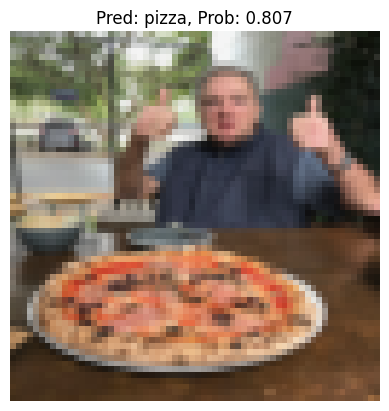

In [ ]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)